## 라이브러리 불러오기

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 데이터 불러오기


In [125]:
data_file_path = 'd:\\proj_mlops\\ajou_mlops_hw02\\data\\raw\\'
data_file = 'titanic.csv'
full_path = data_file_path + data_file
# print(full_path)
df = pd.read_csv(full_path)
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 결측치 확인 및 처리

In [126]:
df.isnull().sum()
# 결측치: age 177, cabin 687, Embarked 2 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

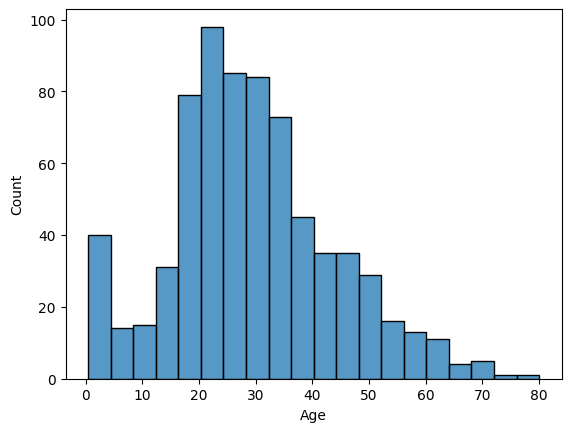

In [127]:
df_na = df.copy()

sns.histplot(df, x='Age')


In [128]:
# Age는 median으로 처리
df_na['Age'] = df_na['Age'].fillna(value=df_na['Age'].median())
df_na['Age'].isnull().sum()

np.int64(0)

In [129]:
# Cabin은 정보가 있는 것과 없는 것으로 구분
df_na['HasCabin'] = df_na['Cabin'].notnull().astype(int) # Null이 아닌 것(True)을 정수형(1)로 변경
df_na = df_na.drop(columns='Cabin')

In [130]:
df_na.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'HasCabin'],
      dtype='str')

In [131]:
# 생존과 관계없다고 여겨지는 컬럼 제거: Embark, Name, Ticket, 
df_na.drop(columns=['Embarked', 'Name', 'Ticket', 'PassengerId'], inplace=True)

In [132]:
df_na.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
HasCabin    0
dtype: int64

In [133]:
df_na.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin
0,0,3,male,22.0,1,0,7.2500,0
1,1,1,female,38.0,1,0,71.2833,1
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,1
4,0,3,male,35.0,0,0,8.0500,0


## 데이터 분리

In [134]:
## 데이터 분리
# X, y 분리
target = 'Survived'
X = df_na.drop(columns=target)
y = df_na[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(712, 7) (712,) (179, 7) (179,)


## 데이터 인코딩
- 수치형 -> 결측치 대체 + Scaling
- 범주형 -> 결측치 대체 + One-hot Encoding

---
타이타닉 데이터셋의 컬럼(변수) 중 범주형(categorical)으로 볼 수 있는 주요 컬럼은 다음과 같습니다:

- Pclass (객실 등급, 1/2/3등급)
- Sex (성별)
- SibSp (함께 탑승한 형제/배우자 수, 값이 적고 구간형으로 볼 수도 있음)
- Parch (함께 탑승한 부모/자녀 수, 값이 적고 구간형으로 볼 수도 있음)
- Ticket (티켓 번호, 보통은 식별자이지만, 분석 목적에 따라 다름)
- Cabin (객실 번호, 결측치 많음, 보통은 범주형 처리)
- Embarked (탑승 항구, S/C/Q)

- 특히, Pclass, Sex, Embarked는 대표적인 범주형 변수입니다.
- Name, Ticket, Cabin은 식별자 또는 텍스트로, 분석 목적에 따라 범주형으로 변환할 수도 있지만 일반적으로는 주요 범주형 변수로 사용하지 않습니다.

- 수치형(연속형) 변수는 Age, Fare 등이 있습니다.

In [135]:
# 범주형(Pclass, Sex) one-hot Encoding
cols = ['Pclass', 'Sex']

### 1. 학습용 데이터 인코딩

In [136]:
X_train_enc = X_train.copy()
X_train_enc = pd.get_dummies(data=X_train_enc, columns=cols)    
X_train_enc.head()

,Age,SibSp,Parch,Fare,HasCabin,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
331,45.5,0,0,28.5000,1,True,False,False,False,True
733,23.0,0,0,13.0000,0,False,True,False,False,True
382,32.0,0,0,7.9250,0,False,False,True,False,True
704,26.0,1,0,7.8542,0,False,False,True,False,True
813,6.0,4,2,31.2750,0,False,False,True,True,False


### 2. 테스트 데이터 인코딩

In [137]:
X_test_enc = X_test.copy()
X_test_enc = pd.get_dummies(data=X_test_enc, columns=cols)
X_test_enc.head()

,Age,SibSp,Parch,Fare,HasCabin,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
709,28.0,1,1,15.2458,0,False,False,True,False,True
439,31.0,0,0,10.5000,0,False,True,False,False,True
840,20.0,0,0,7.9250,0,False,False,True,False,True
720,6.0,0,1,33.0000,0,False,True,False,True,False
39,14.0,1,0,11.2417,0,False,False,True,True,False


## 데이터 스케일링

In [138]:
from sklearn.preprocessing import StandardScaler

### StandardScaler

In [139]:
X_train_scale = X_train_enc.copy()
ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train_scale)

X_test_scale = X_test_enc.copy()
X_test_scale = ss.transform(X_test_scale)

### MinMaxScaler

In [146]:
from sklearn.preprocessing import MinMaxScaler

In [147]:
X_train_mms = X_train_enc.copy()
mms = MinMaxScaler()
X_train_mms = mms.fit_transform(X_train_mms)

X_test_mms = X_test_enc.copy()
X_test_mms = mms.transform(X_test_mms)

## 모델 학습

In [143]:
# SVC 학습과 모델 평가를 위한 라이브러리
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

### SVM without scaling

In [144]:
# 모델 생성
svm_clf_wo_scale = SVC(random_state=42)
svm_clf_wo_scale.fit(X_train_enc, y_train)

# 예측
y_pred_svm_wo_scale = svm_clf_wo_scale.predict(X_test_enc)

#평가
print('Acc: ', accuracy_score(y_test, y_pred_svm_wo_scale))
print(classification_report(y_test, y_pred_svm_wo_scale))

Acc:  0.6536312849162011
              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.75      0.24      0.37        74

    accuracy                           0.65       179
   macro avg       0.69      0.59      0.56       179
weighted avg       0.68      0.65      0.60       179



### SVM with StandardScaler

In [ ]:
# 모델 생성
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train_scale, y_train)

# 예측
y_pred_svm = svm_clf.predict(X_test_scale)

#평가
print('Acc: ', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Acc:  0.8100558659217877
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### SVM with MinMaxScaler

In [148]:
# 모델 생성
svm_clf_mms = SVC(random_state=42)
svm_clf_mms.fit(X_train_mms, y_train)

# 예측
y_pred_svm_mms = svm_clf_mms.predict(X_test_mms)

#평가
print('Acc: ', accuracy_score(y_test, y_pred_svm_mms))
print(classification_report(y_test, y_pred_svm_mms))

Acc:  0.7932960893854749
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



### KNN with StandardScaler

In [141]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scale, y_train)

y_pred_knn = knn_clf.predict(X_test_scale)

print('KNN acc: ', accuracy_score(y_test, y_pred_knn));
print(classification_report(y_test, y_pred_knn))

KNN acc:  0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### KNN with MinMaxScaler

In [149]:
knn_clf_mms = KNeighborsClassifier(n_neighbors=5)
knn_clf_mms.fit(X_train_mms, y_train)

y_pred_knn_mms = knn_clf_mms.predict(X_test_mms)

print('KNN acc: ', accuracy_score(y_test, y_pred_knn_mms));
print(classification_report(y_test, y_pred_knn_mms))

KNN acc:  0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



## 결과 비교

In [151]:
print("Accuracy")
print('='*30)
print('SVM(No scale): ', np.round(accuracy_score(y_test, y_pred_svm_wo_scale), 3))
print('SVM(StandardScaler): ', np.round(accuracy_score(y_test, y_pred_svm), 3))
print('SVM(MinMaxScaler): ', np.round(accuracy_score(y_test, y_pred_svm_mms), 3))
print('KNN(StandardScaler): ', np.round(accuracy_score(y_test, y_pred_knn), 3))
print('KNN(MinMaxScaler): ', np.round(accuracy_score(y_test, y_pred_knn_mms), 3))
print('='*30)
print("Classification Report")
print('='*30)
print("1. SVM(No scale)")
print(classification_report(y_test, y_pred_svm_wo_scale))
print("SVM(StandardScaler)")
print(classification_report(y_test, y_pred_svm))
print("SVM(MinMaxScaler)")
print(classification_report(y_test, y_pred_svm_mms))
print("KNN(StandardScaler)")
print(classification_report(y_test, y_pred_knn))
print("KNN(MinMaxScaler)")
print(classification_report(y_test, y_pred_knn_mms))

Accuracy
SVM(No scale):  0.654
SVM(StandardScaler):  0.81
SVM(MinMaxScaler):  0.793
KNN(StandardScaler):  0.821
KNN(MinMaxScaler):  0.804
Classification Report
1. SVM(No scale)
              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.75      0.24      0.37        74

    accuracy                           0.65       179
   macro avg       0.69      0.59      0.56       179
weighted avg       0.68      0.65      0.60       179

SVM(StandardScaler)
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

SVM(MinMaxScaler)
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.7